## 1. IMPORT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

## 2. ĐỌC DỮ LIỆU

In [2]:
customer = pd.read_csv('../data/customer.csv')
df_success = pd.read_csv('../data/df_success.csv')
customer.head()

,Customer ID,Country,Recency,Monetary,Frequency
0,12346.0,United Kingdom,165,372.86,11
1,12347.0,Iceland,3,1323.32,2
2,12348.0,Finland,74,222.16,1
3,12349.0,Italy,43,2671.14,3
4,12351.0,Unspecified,11,300.93,1


In [3]:
df_success.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Amount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [4]:
df_success['InvoiceDate'] = pd.to_datetime(df_success['InvoiceDate'])

## 3. TẠO FEATURE CHO 6 THÁNG ĐẦU

Dùng 6 tháng đầu để tạo feature, dự đoán doanh thu 6 tháng cuối (chia theo mốc thời gian, không chia ngẫu nhiên).

In [5]:
now = df_success['InvoiceDate'].max() + pd.Timedelta(days=1)
six_months_ago = now - pd.Timedelta(days=180)

In [6]:
# Dữ liệu 6 tháng đầu (dùng để tạo feature)
first_6_months = df_success[df_success['InvoiceDate'] < six_months_ago].copy()

rfm_train = first_6_months.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (now - x.max()).days,
    'Amount': 'sum',
    'Invoice': 'nunique',
    'Quantity': 'mean',
}).rename(columns={
    'InvoiceDate': 'Recency',
    'Amount': 'Monetary',
    'Invoice': 'Frequency',
    'Quantity': 'Avg_Quantity',
})
rfm_train.head()

,Recency,Monetary,Frequency,Avg_Quantity
Customer ID,,,,
12346.0,283,230.55,10,3.642857
12349.0,206,1268.52,2,10.085106
12355.0,203,488.21,1,13.772727
12358.0,186,1697.93,2,16.857143
12359.0,262,1522.23,4,11.772727


In [7]:
# Feature: trung bình số ngày giữa 2 lần mua
first_6_months = first_6_months.sort_values(['Customer ID', 'InvoiceDate'])
first_6_months['Prev_InvoiceDate'] = first_6_months.groupby('Customer ID')['InvoiceDate'].shift(1)
first_6_months['Days_Between'] = (first_6_months['InvoiceDate'] - first_6_months['Prev_InvoiceDate']).dt.days

avg_days_between = first_6_months.groupby('Customer ID')['Days_Between'].mean()
rfm_train['Avg_Days_Between'] = avg_days_between

In [8]:
# Feature: số sản phẩm khác nhau đã mua
unique_products = first_6_months.groupby('Customer ID')['StockCode'].nunique()
rfm_train['Unique_Products'] = unique_products

In [9]:
# Feature: quốc gia của khách hàng
rfm_train['Country'] = first_6_months.groupby('Customer ID')['Country'].first()
rfm_train.head()

,Recency,Monetary,Frequency,Avg_Quantity,Avg_Days_Between,Unique_Products,Country
Customer ID,,,,,,,
12346.0,283,230.55,10,3.642857,5.692308,7,United Kingdom
12349.0,206,1268.52,2,10.085106,0.391304,47,Italy
12355.0,203,488.21,1,13.772727,0.000000,22,Bahrain
12358.0,186,1697.93,2,16.857143,5.323529,34,Austria
12359.0,262,1522.23,4,11.772727,1.630769,65,Cyprus


## 4. TẠO TARGET (6 THÁNG CUỐI)

In [10]:
last_6_months = df_success[df_success['InvoiceDate'] >= six_months_ago]
target_raw = last_6_months.groupby('Customer ID')['Amount'].sum()

# Giữ lại toàn bộ khách hàng, gán 0 cho người không mua tiếp (không âm thầm bỏ đi)
target = target_raw.reindex(rfm_train.index).fillna(0)

khong_quay_lai = (target == 0).sum()
print(f"Tổng số khách hàng: {len(target)}")
print(f"Số khách hàng không quay lại mua: {khong_quay_lai} ({khong_quay_lai/len(target)*100:.1f}%)")
print(f"Số khách hàng còn mua tiếp: {len(target) - khong_quay_lai}")

Tổng số khách hàng: 2830
Số khách hàng không quay lại mua: 833 (29.4%)
Số khách hàng còn mua tiếp: 1997


## 5. XỬ LÝ FEATURE

In [11]:
# Fill missing Avg_Days_Between (khách chỉ mua 1 lần thì không có khoảng cách giữa 2 lần mua)
rfm_train['Avg_Days_Between'] = rfm_train['Avg_Days_Between'].fillna(365)

# One-hot encode Country
rfm_train = pd.get_dummies(rfm_train, columns=['Country'], drop_first=True)

## 6. CHUẨN BỊ DỮ LIỆU CHO MODEL

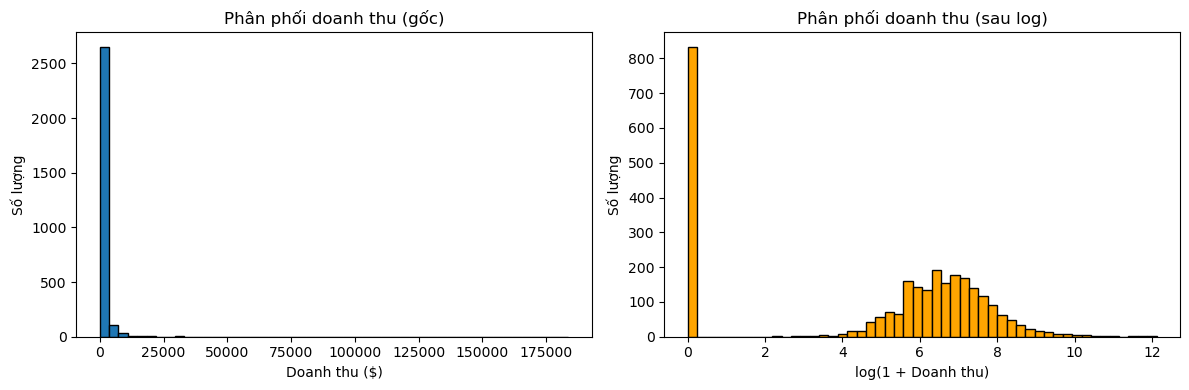

Doanh thu trung bình: $1343.18
Doanh thu trung vị: $420.95
Doanh thu cao nhất: $183702.18
% khách hàng có doanh thu = 0: 29.4%


In [12]:
X = rfm_train.copy()
y = target.copy()

# Log transform cho target (doanh thu bị lệch phải rất nặng, vài khách VIP chi rất nhiều)
y_log = np.log1p(y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(y, bins=50, edgecolor='black')
ax1.set_title('Phân phối doanh thu (gốc)')
ax1.set_xlabel('Doanh thu ($)')
ax1.set_ylabel('Số lượng')

ax2.hist(y_log, bins=50, edgecolor='black', color='orange')
ax2.set_title('Phân phối doanh thu (sau log)')
ax2.set_xlabel('log(1 + Doanh thu)')
ax2.set_ylabel('Số lượng')

plt.tight_layout()
plt.show()

print(f"Doanh thu trung bình: ${y.mean():.2f}")
print(f"Doanh thu trung vị: ${y.median():.2f}")
print(f"Doanh thu cao nhất: ${y.max():.2f}")
print(f"% khách hàng có doanh thu = 0: {(y == 0).sum() / len(y) * 100:.1f}%")

## 7. CHIA TRAIN/TEST

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

## 8. SCALE FEATURE

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 9. TRAIN VÀ SO SÁNH CÁC MODEL

In [15]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
}

In [16]:
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred_log = model.predict(X_test_scaled)

    # Chuyển ngược về đơn vị $ để đánh giá
    y_pred = np.expm1(y_pred_log)
    y_test_original = np.expm1(y_test)

    r2 = r2_score(y_test_original, y_pred)
    mae = mean_absolute_error(y_test_original, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))

    results[name] = {
        'R2 Score': r2,
        'MAE ($)': mae,
        'RMSE ($)': rmse
    }

## 10. HIỂN THỊ KẾT QUẢ

In [17]:
results_df = pd.DataFrame(results).T
print("KẾT QUẢ ĐÁNH GIÁ MODEL:")
print(results_df.round(2))

KẾT QUẢ ĐÁNH GIÁ MODEL:
                     R2 Score    MAE ($)    RMSE ($)
Linear Regression -1103536.79  169225.57  3997040.44
Random Forest            0.50     943.60     2678.51
Gradient Boosting        0.37     979.78     3012.28


## 11. CHỌN MODEL TỐT NHẤT

In [18]:
best_model_name = results_df['R2 Score'].idxmax()
best_model = models[best_model_name]
print(f"Model tốt nhất: {best_model_name}")
print(f"R2 Score: {results_df.loc[best_model_name, 'R2 Score']:.4f}")
print(f"RMSE: ${results_df.loc[best_model_name, 'RMSE ($)']:.2f}")

Model tốt nhất: Random Forest
R2 Score: 0.5044
RMSE: $2678.51


## 12. FEATURE IMPORTANCE

TOP FEATURE QUAN TRỌNG NHẤT:
                   Feature  Importance
1                 Monetary    0.435008
0                  Recency    0.152506
3             Avg_Quantity    0.150626
5          Unique_Products    0.117123
4         Avg_Days_Between    0.077392
2                Frequency    0.038473
32  Country_United Kingdom    0.006572
15         Country_Germany    0.002990
6          Country_Austria    0.002447
28          Country_Sweden    0.002405


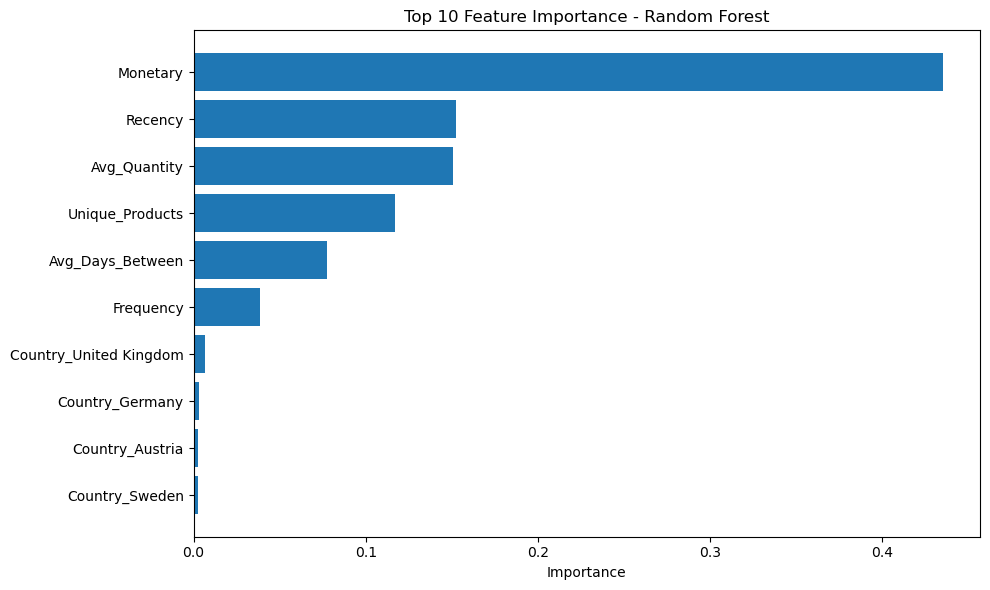

In [19]:
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("TOP FEATURE QUAN TRỌNG NHẤT:")
    print(feature_importance.head(10))

    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
    plt.xlabel('Importance')
    plt.title(f'Top 10 Feature Importance - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 13. LƯU MODEL

In [20]:
import joblib

artifacts = {
    'model': best_model,
    'scaler': scaler,
    'feature_names': X.columns.tolist(),
    'model_name': best_model_name,
    'target_transformer': 'log1p'
}

joblib.dump(artifacts, '../models/regressor_model.pkl')
print("Đã lưu model vào 'models/regressor_model.pkl'")

Đã lưu model vào 'models/regressor_model.pkl'


## 14. KIỂM TRA MODEL TRÊN TEST SET

So sánh 10 khách hàng ngẫu nhiên:
      Actual  Predicted
63   2722.73    1041.27
271    75.00     140.13
320   521.10     605.43
349  2097.60    1186.42
354  1144.48      26.76
375   491.40     863.43
546     0.00      24.91
151   501.52     153.92
504    15.00      64.66
92      0.00     339.27


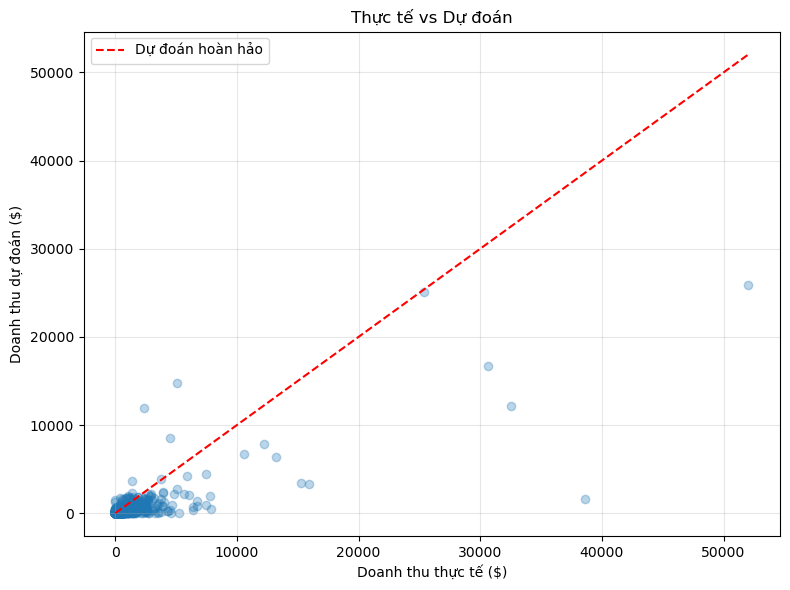

In [21]:
y_pred_log = best_model.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

compare_df = pd.DataFrame({
    'Actual': y_test_original,
    'Predicted': y_pred
}).reset_index(drop=True)

print("So sánh 10 khách hàng ngẫu nhiên:")
print(compare_df.sample(10).round(2))

plt.figure(figsize=(8, 6))
plt.scatter(compare_df['Actual'], compare_df['Predicted'], alpha=0.3)
plt.plot([0, compare_df['Actual'].max()], [0, compare_df['Actual'].max()], 'r--', label='Dự đoán hoàn hảo')
plt.xlabel('Doanh thu thực tế ($)')
plt.ylabel('Doanh thu dự đoán ($)')
plt.title('Thực tế vs Dự đoán')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()